# =====================================
# Case Study: NYC Restaurant Food Safety Analysis
# Author: Hoang Do Phan
# Date: June 2026
# =====================================

# STEP 1: ASK

## 1.1 Background

This project analyzes New York City restaurant inspection data from the Department of Health and Mental Hygiene (DOHMH).

The goal is to understand food safety performance across restaurants, cuisines, boroughs, and neighborhoods.

## 1.2 Business Task

Analyze NYC restaurant inspection data to identify common food safety violations, low-performing cuisines, high-risk boroughs/neighborhoods, and provide recommendations to improve food safety.

## 1.3 Business Objectives

- Which violations are most common?
- Which boroughs or neighborhoods have the highest food safety risk?
- Which cuisines have the lowest inspection performance?
- How do grades, scores, and violations change over time?
- Where should the city focus inspections, policies, or education?

## 1.4 Deliverables

- Summary of the business task
- Description of the data source
- Data cleaning documentation
- Analysis summary
- Supporting visualizations
- Recommendations

## 1.5 Key Stakeholders

- NYC Health Commissioner
- NYC Department of Health and Mental Hygiene
- Restaurant inspection teams
- Public health policy teams
- NYC residents and restaurant customers

# STEP 2: PREPARE

## 2.1 Information on Data Source

The dataset used in this project is the NYC Restaurant Inspection Results dataset provided through Analyst Builder.

The dataset contains inspection records collected by the New York City Department of Health and Mental Hygiene (DOHMH). It includes restaurant information, inspection results, violation details, grades, and geographic information used to evaluate food safety performance across New York City.

## 2.2 Data Selection

This project utilizes the NYC Restaurant Inspection Results dataset.

Selected fields include:

- CAMIS
- DBA
- BORO
- BUILDING
- STREET
- ZIPCODE
- PHONE
- CUISINE DESCRIPTION
- INSPECTION DATE
- ACTION
- VIOLATION CODE
- VIOLATION DESCRIPTION
- CRITICAL FLAG
- SCORE
- GRADE
- GRADE DATE
- RECORD DATE
- INSPECTION TYPE
- Latitude
- Longitude
- Community Board
- Council District
- Census Tract
- BIN
- BBL
- NTA
- Location Point1

These fields support the analysis of restaurant performance, food safety violations, geographic trends, and inspection outcomes.

## 2.3 Limitations of the Dataset

- Some records contain missing values.
- Multiple records may exist for a single inspection because each violation is stored separately.
- Missing grades do not necessarily indicate poor restaurant performance.
- Data quality issues require cleaning before analysis.

## 2.4 Is the Data ROCCC?

| Criteria | Evaluation |
|-----------|------------|
| Reliable | High – Data provided by NYC DOHMH |
| Original | High – Collected by the official inspection authority |
| Comprehensive | High – Includes inspections, grades, violations, and location data |
| Current | Medium – Depends on dataset update frequency |
| Cited | High – Dataset source is documented |

Overall, the dataset is suitable for food safety analysis and business intelligence reporting.

# STEP 3: PROCESS

## 3.1 Import Libraries

The required libraries are imported to load, clean, and analyze the dataset.

In [1]:
import pandas as pd
import numpy as np

## 3.2 Load Dataset

The NYC Restaurant Inspection Results dataset is loaded into a Pandas DataFrame for further analysis.

In [4]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))

df.head()

Saving DOHMH_New_York_City_Restaurant_Inspection_Results_20250919.csv to DOHMH_New_York_City_Restaurant_Inspection_Results_20250919.csv


,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location Point1
0,50104876,NOODLE SUPER NO I,Manhattan,265,1 AVENUE,10003.0,2125290539,Chinese,08/24/2022,Violations were cited in the following area(s).,...,Pre-permit (Operational) / Second Compliance I...,40.732264,-73.981768,106.0,2.0,4800.0,1020423.0,1.009220e+09,MN21,NaN
1,50174387,TREATS OF KOREA,Queens,3150,STEINWAY ST,11103.0,8453232965,NaN,01/01/1900,NaN,...,NaN,40.760128,-73.918066,401.0,22.0,15500.0,4010534.0,4.006580e+09,QN70,NaN
2,50122756,MELLER'S SPORTS HUB & GRILL,Manhattan,1702,2 AVENUE,10128.0,9175964244,American,08/04/2025,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.779327,-73.950670,108.0,5.0,14602.0,1050066.0,1.015510e+09,MN32,NaN
3,41408131,CHRIS RESTAURANT,Brooklyn,1866,86 STREET,11214.0,3474623755,Polish,05/20/2024,Violations were cited in the following area(s).,...,Cycle Inspection / Re-inspection,40.606285,-74.001070,311.0,38.0,27800.0,3340602.0,3.063710e+09,BK28,NaN
4,50138007,PEARL OF CHINA,Brooklyn,8411,3 AVENUE,11209.0,7188334281,Chinese,08/16/2023,Violations were cited in the following area(s).,...,Pre-permit (Operational) / Initial Inspection,40.624850,-74.030476,310.0,47.0,6200.0,3152743.0,3.060250e+09,BK31,NaN


## 3.3 Check Dataset Dimensions

The shape function is used to determine the number of rows and columns contained in the dataset.

In [5]:
df.shape

(288888, 27)

## 3.4 Review Dataset Structure

The info() function provides information about column names, data types, and non-null values.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288888 entries, 0 to 288887
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  288888 non-null  int64  
 1   DBA                    288882 non-null  object 
 2   BORO                   288888 non-null  object 
 3   BUILDING               288379 non-null  object 
 4   STREET                 288885 non-null  object 
 5   ZIPCODE                285977 non-null  float64
 6   PHONE                  288882 non-null  object 
 7   CUISINE DESCRIPTION    285189 non-null  object 
 8   INSPECTION DATE        288888 non-null  object 
 9   ACTION                 285189 non-null  object 
 10  VIOLATION CODE         283037 non-null  object 
 11  VIOLATION DESCRIPTION  283037 non-null  object 
 12  CRITICAL FLAG          288888 non-null  object 
 13  SCORE                  272962 non-null  float64
 14  GRADE                  140844 non-nu

## 3.5 Check Missing Values

Missing values are identified to determine which columns require cleaning before analysis.

In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
Location Point1,288888
GRADE DATE,155868
GRADE,148044
SCORE,15926
VIOLATION CODE,5851
VIOLATION DESCRIPTION,5851
BIN,5122
Community Board,3715
NTA,3715
Census Tract,3714


## Findings

Several columns contain missing values.

Location Point1 is entirely missing and will be removed. Grade, Grade Date, and Score also contain missing values and will be reviewed during the data cleaning process.

## 3.6 Check Duplicate Records

Duplicate rows are checked to ensure data quality.

In [8]:
df.duplicated().sum()

np.int64(6)

## 3.7 Review Column Names

Column names are reviewed before the cleaning process begins.

In [9]:
df.columns

Index(['CAMIS', 'DBA', 'BORO', 'BUILDING', 'STREET', 'ZIPCODE', 'PHONE',
       'CUISINE DESCRIPTION', 'INSPECTION DATE', 'ACTION', 'VIOLATION CODE',
       'VIOLATION DESCRIPTION', 'CRITICAL FLAG', 'SCORE', 'GRADE',
       'GRADE DATE', 'RECORD DATE', 'INSPECTION TYPE', 'Latitude', 'Longitude',
       'Community Board', 'Council District', 'Census Tract', 'BIN', 'BBL',
       'NTA', 'Location Point1'],
      dtype='object')

## 3.8 Initial Findings

The dataset contains restaurant inspection records, violation information, grades, scores, and geographic data.

Several columns contain missing values and may require cleaning before analysis. The next step focuses on transforming and cleaning the data to prepare it for analysis.

# STEP 4: PROCESS
## 4.1 Remove Duplicate Records

Duplicate records are removed to improve data quality.

In [11]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

## 4.2 Remove Unnecessary Columns

Columns that do not contribute to the analysis are removed.

In [17]:
df = df.drop(columns=['location_point1'])

In [18]:
'location_point1' in df.columns

False

In [27]:
df = df[df['boro'] != '0']

## 4.3 Convert Date Columns

Date columns are converted to datetime format for time-based analysis.

In [20]:
date_columns = [
    'inspection_date',
    'grade_date',
    'record_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

## 4.4 Handle Missing Values

Missing values in selected categorical columns are replaced to improve consistency and support analysis.

In [22]:
df['grade'] = df['grade'].fillna('Not Graded')

df['cuisine_description'] = df['cuisine_description'].fillna('Unknown')

df['inspection_type'] = df['inspection_type'].fillna('Unknown')

df['violation_description'] = df['violation_description'].fillna('No Violation Recorded')

### Findings

Missing values in key categorical fields were replaced with descriptive labels to maintain data consistency while preserving records for analysis.

## 4.6 Create New Features

Additional date features are created to support trend analysis and time-based visualizations.

In [23]:
df['inspection_year'] = df['inspection_date'].dt.year

df['inspection_month'] = df['inspection_date'].dt.month

df['inspection_month_name'] = df['inspection_date'].dt.month_name()

## 4.7 Create Critical Violation Indicator

A new indicator is created to identify whether a violation is classified as critical.

In [24]:
df['is_critical'] = (
    df['critical_flag']
    .str.contains('Critical', case=False, na=False)
)

## 4.8 Review Cleaned Dataset

The cleaned dataset is reviewed before moving to the analysis phase.

In [25]:
df.info()
df.head()
df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 288882 entries, 0 to 288887
Data columns (total 30 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   camis                  288882 non-null  int64         
 1   dba                    288876 non-null  object        
 2   boro                   288882 non-null  object        
 3   building               288373 non-null  object        
 4   street                 288879 non-null  object        
 5   zipcode                285977 non-null  float64       
 6   phone                  288876 non-null  object        
 7   cuisine_description    288882 non-null  object        
 8   inspection_date        288882 non-null  datetime64[ns]
 9   action                 285183 non-null  object        
 10  violation_code         283031 non-null  object        
 11  violation_description  288882 non-null  object        
 12  critical_flag          288882 non-null  object   

(288882, 30)

# STEP 5: ANALYZE

## 5.1 Total Inspections by Borough

This analysis identifies which boroughs receive the highest number of restaurant inspections.

In [31]:
inspections_by_borough = (
    df.groupby('boro')
    .size()
    .reset_index(name='total_inspections')
    .sort_values('total_inspections', ascending=False)
)

inspections_by_borough

,boro,total_inspections
2,Manhattan,106792
1,Brooklyn,74890
3,Queens,70696
0,Bronx,26425
4,Staten Island,10064


## 5.2 Grade Distribution

This analysis examines the distribution of restaurant grades across New York City.

In [32]:
grade_distribution = (
    df['grade']
    .value_counts()
    .reset_index()
)

grade_distribution.columns = ['grade', 'count']

grade_distribution

,grade,count
0,Not Graded,148023
1,A,95761
2,B,17602
3,C,12118
4,N,7824
5,Z,6626
6,P,913


## 5.3 Inspection Type Distribution

This analysis identifies the most common types of restaurant inspections.

In [33]:
inspection_type_distribution = (
    df['inspection_type']
    .value_counts()
    .reset_index()
)

inspection_type_distribution.columns = ['inspection_type', 'count']

inspection_type_distribution

,inspection_type,count
0,Cycle Inspection / Initial Inspection,152433
1,Cycle Inspection / Re-inspection,59290
2,Pre-permit (Operational) / Initial Inspection,38336
3,Pre-permit (Operational) / Re-inspection,10772
4,Administrative Miscellaneous / Initial Inspection,8333
5,Pre-permit (Non-operational) / Initial Inspection,3698
6,Unknown,3684
7,Cycle Inspection / Reopening Inspection,2756
8,Pre-permit (Operational) / Compliance Inspection,1972
9,Administrative Miscellaneous / Re-inspection,1782


## 5.4 Top 10 Most Common Violations

This analysis identifies the violations that occur most frequently across NYC restaurants.

In [34]:
top_violations = (
    df['violation_description']
    .value_counts()
    .head(10)
    .reset_index()
)

top_violations.columns = ['violation_description', 'count']

top_violations

,violation_description,count
0,Non-food contact surface or equipment made of ...,35758
1,Establishment is not free of harborage or cond...,24103
2,"Food contact surface not properly washed, rins...",18595
3,Cold TCS food item held above 41 °F; smoked or...,16240
4,Anti-siphonage or back-flow prevention device ...,16045
5,Evidence of mice or live mice in establishment...,13647
6,Hot TCS food item not held at or above 140 °F.,13557
7,"Food, supplies, or equipment not protected fro...",12290
8,Filth flies or food/refuse/sewage associated w...,7815
9,Food Protection Certificate (FPC) not held by ...,7153


## 5.5 Critical vs Non-Critical Violations

This analysis compares critical and non-critical violations.

In [35]:
critical_distribution = (
    df['critical_flag']
    .value_counts()
    .reset_index()
)

critical_distribution.columns = ['critical_flag', 'count']

critical_distribution

,critical_flag,count
0,Critical,153135
1,Not Critical,128154
2,Not Applicable,7578


## 5.6 Critical Violations by Borough

This analysis identifies which boroughs have the highest number of critical violations.

In [36]:
critical_by_borough = (
    df.groupby('boro')['is_critical']
    .sum()
    .reset_index(name='critical_violations')
    .sort_values('critical_violations', ascending=False)
)

critical_by_borough

,boro,critical_violations
2,Manhattan,103492
1,Brooklyn,73030
3,Queens,69002
0,Bronx,25904
4,Staten Island,9861


## 5.7 Lowest Performing Cuisines

This analysis identifies cuisines with the highest average inspection scores.

In [37]:
worst_cuisines = (
    df.groupby('cuisine_description')
    .agg(
        total_records=('cuisine_description', 'count'),
        average_score=('score', 'mean')
    )
    .reset_index()
)

worst_cuisines = worst_cuisines[
    worst_cuisines['total_records'] >= 100
]

worst_cuisines = worst_cuisines.sort_values(
    'average_score',
    ascending=False
).head(10)

worst_cuisines

,cuisine_description,total_records,average_score
8,Bangladeshi,1552,41.812795
1,African,1391,35.695094
64,Pakistani,549,34.864151
32,Filipino,610,34.468158
20,Chinese/Cuban,221,32.869159
29,Egyptian,142,32.824818
44,Indian,4467,31.944753
24,Creole,438,31.847775
28,Eastern European,1357,30.578626
70,Russian,553,29.236742


## 5.8 Critical Violation Rate by Cuisine

This analysis identifies cuisines with the highest proportion of critical violations.

In [38]:
critical_rate_by_cuisine = (
    df.groupby('cuisine_description')
    .agg(
        total_records=('cuisine_description', 'count'),
        critical_violations=('is_critical', 'sum')
    )
    .reset_index()
)

critical_rate_by_cuisine['critical_rate'] = (
    critical_rate_by_cuisine['critical_violations']
    / critical_rate_by_cuisine['total_records']
) * 100

critical_rate_by_cuisine = critical_rate_by_cuisine[
    critical_rate_by_cuisine['total_records'] >= 100
]

critical_rate_by_cuisine = critical_rate_by_cuisine.sort_values(
    'critical_rate',
    ascending=False
).head(10)

critical_rate_by_cuisine

,cuisine_description,total_records,critical_violations,critical_rate
30,English,127,127,100.000000
21,Chinese/Japanese,622,620,99.678457
24,Creole,438,436,99.543379
31,Ethiopian,161,160,99.378882
8,Bangladeshi,1552,1542,99.355670
44,Indian,4467,4438,99.350795
38,Greek,1516,1506,99.340369
50,Jewish/Kosher,4129,4101,99.321870
33,French,2899,2879,99.310107
29,Egyptian,142,141,99.295775


## 5.9 Inspection Trend Over Time

This analysis examines inspection activity over time.

In [39]:
monthly_trend = (
    df.groupby(['inspection_year', 'inspection_month'])
    .size()
    .reset_index(name='total_inspections')
)

monthly_trend

,inspection_year,inspection_month,total_inspections
0,1900,1,3684
1,2015,9,5
2,2015,10,3
3,2015,11,6
4,2015,12,4
...,...,...,...
107,2025,5,7922
108,2025,6,6897
109,2025,7,8907
110,2025,8,8448


## Findings

The analysis identifies common violations, borough-level inspection activity, cuisine performance, and critical food safety risks. These results will be used to create an interactive Tableau dashboard and develop recommendations for improving food safety across New York City.

# STEP 6: SHARE

## 6.1 Export Cleaned Dataset

The cleaned dataset is exported as a CSV file so it can be used in Tableau for dashboard creation.

In [40]:
df.to_csv('nyc_restaurant_inspections_cleaned.csv', index=False)
from google.colab import files

files.download('nyc_restaurant_inspections_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6.2 Tableau Dashboard

The cleaned dataset was imported into Tableau to create a dashboard showing restaurant inspection performance, common violations, cuisine risk, borough comparison, and inspection trends.

The dashboard includes:

- Total inspections by borough
- Grade distribution
- Top 10 violations
- Critical violations by borough
- Lowest-performing cuisines
- Inspection trends over time

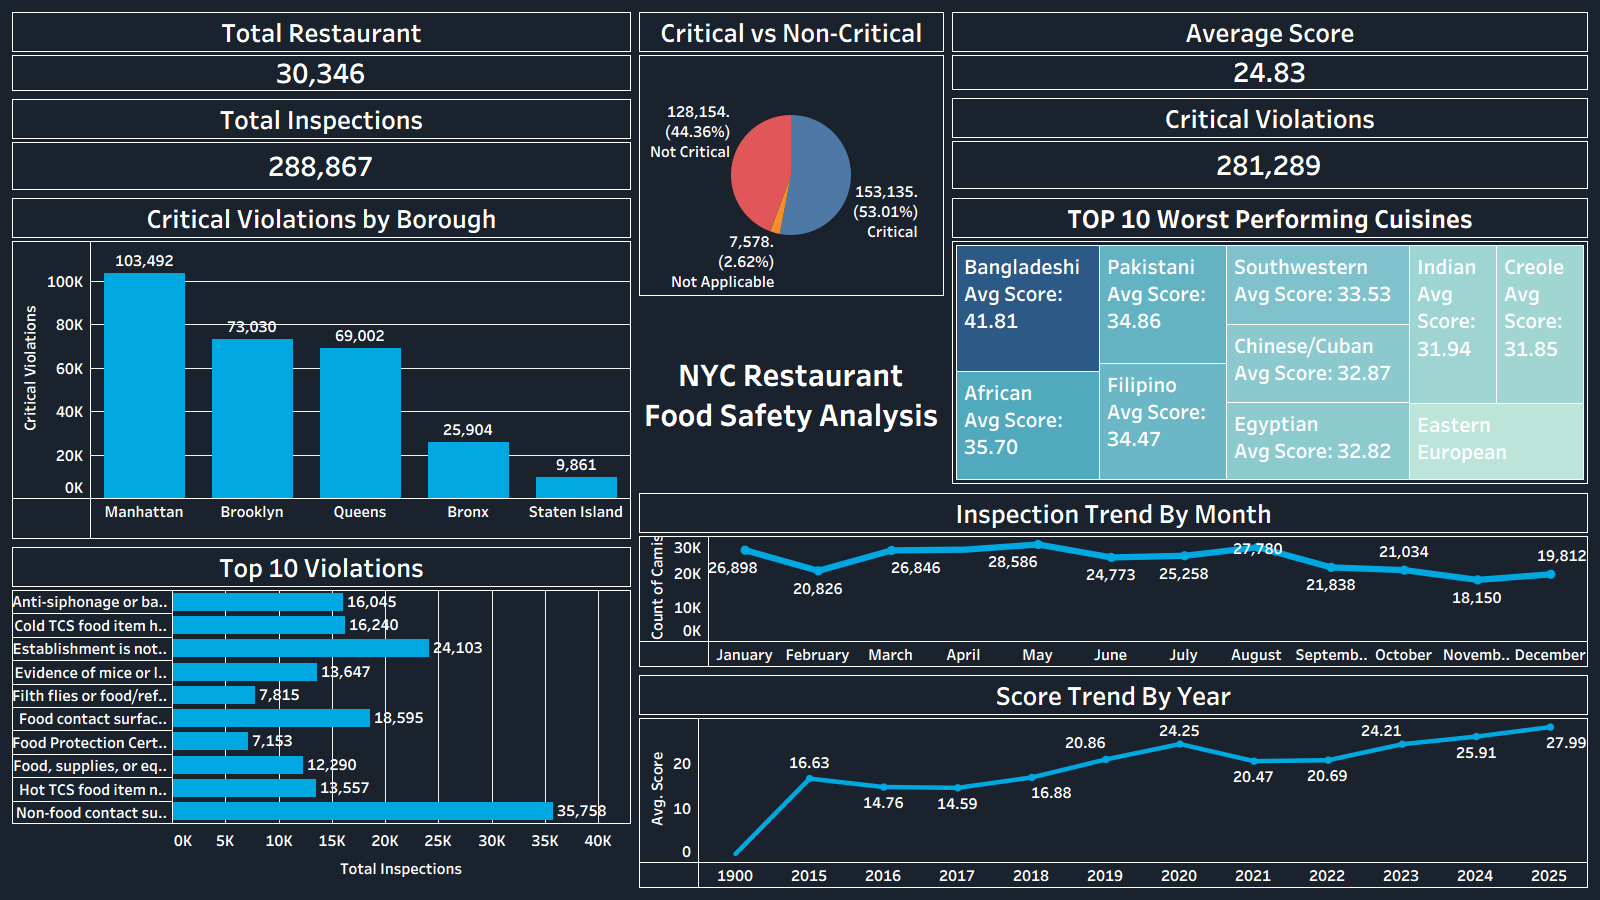

# STEP 7: ACT

## Conclusion

This analysis identified key food safety trends across New York City restaurants.

Manhattan recorded the highest number of inspections, while several boroughs showed higher concentrations of critical violations. Common violations were primarily related to food protection, sanitation, and operational compliance.

The analysis also revealed differences in inspection performance across cuisine types, suggesting that some restaurant categories may require additional food safety training and monitoring.

## Recommendations

- Increase inspections in areas with higher levels of critical violations.
- Provide targeted food safety education for lower-performing cuisine categories.
- Monitor recurring violations to improve compliance and reduce public health risks.
- Continue tracking inspection trends to support data-driven policy decisions.

Overall, these findings can help improve restaurant food safety standards and support better public health outcomes across New York City.